# Drone Compute Thermal Modeling

Lo-fi thermal modeling of embedded compute on a drone.

Builds intuition for four distinct operating modes determined by the interplay of:
  - **cooling capacity**    (thermal resistance $R$, driven by airflow)
  - **power dissipation**   ($P$, possibly reduced by throttling)
  - **ambient temperature** ($T_a$)
  - **hardware limits**     ($T_\text{thresh}$ for throttle onset, $T_\text{safe}$ for max-rated temp)

The four modes to simulate and analyze are:

  1. Safe   steady state, WITHOUT throttling  — cool enough that throttle never fires
  2. Safe   steady state, WITH    throttling  — throttle engages and holds T below T_safe
  3. Unsafe steady state, WITHOUT throttling  — equilibrium exists but above T_safe
  4. Unsafe steady state, WITH    throttling  — even throttled power exceeds cooling capacity

The RC model to use:
  
$$C \frac{dT}{dt}  =  P(t)  −  (T − T_a)/R$$

## Hardware Thermal Thresholds

These are properties of the compute SoC / SoM and are found in:

- $T_\text{thresh}$: "Thermal throttle onset" in the vendor BSP / device tree.
  - Deriving empirically: run a CPU stress benchmark while logging clock frequency; the knee where clocks begin dropping is T_thresh.
  - Tool on Linux: `watch -n0.5 cat /sys/class/thermal/thermal_zone*/temp`
- $T_\text{safe}$: "Absolute Maximum Operating Temperature" in the datasheet. Exceeding this causes thermal shutdown, latch-up, or permanent damage. Never design to operate near this value.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

T_THRESH = 80.0   # [°C] throttle onset temperature
T_SAFE   = 95.0   # [°C] maximum safe operating temperature (TjMax)

## Power Model Constants

First-order power model:

$$P(\text{load}) = P_\text{idle} + \alpha * \text{load},$$

$$\text{load} ∈ [0, 1]$$

How to derive $P_\text{idle}$ and $P_\text{max}$ empirically:

1. Power off all non-essential peripherals.
2. Connect a USB power meter or a bench supply with current readout.
3. Boot to OS prompt (no workload) → read $P_\text{idle}$.
4. Run `stress-ng --cpu 0 --timeout 120s` or a GPU inference benchmark → $P_\text{max}$.
5. Optional: sweep CPU frequency / core count and fit a line to get $\alpha$.

$P_\text{throttle}$ is the power the chip runs at after throttling fully engages. It corresponds to the lowest Operating Performance Point (OPP) the OS scheduler allows while the thermal trip is active.  Typically 40–60 % of $P_\text{max}$.

In [3]:
P_IDLE     =  5.0  # [W] idle power  (OS running, no workload)
P_MAX      = 50.0  # [W] full-load power (CPU + GPU + DRAM + peripherals)
P_THROTTLE = 28.0  # [W] power at full throttle (~56 % of P_max here)

# Width of the smooth throttle transition [°C].
# Real DVFS controllers ramp down gradually, not in a hard step.
# A width of 3–5 °C matches measured frequency-vs-temperature curves well.
THROTTLE_WIDTH = 3.0  # [°C]

## Thermal Resistance

$R$ [K/W] sets the steady-state temperature rise per watt:

$$T_\text{ss} = T_a + P R$$

How to measure $R$ empirically:

- Method A — steady-state step test (simplest):
  - Apply a known constant power $P$ (e.g. run the stress test).
  - Wait until temperature stops changing ($t \gg \tau$).
  - $R = (T_\text{ss} − T_a) / P$
- Method B — cool-down curve (good when you can't hold $P$ perfectly steady):
  - Heat the device to a known temperature $T_\text{hot}$, then cut power suddenly.
  - Fit the exponential decay:  $T(t) = T_a + (T_\text{hot} − T_a) · \exp(−t/\tau)$
  - Once $\tau$ and $C$ are known: $R = \tau / C$
- Method C — analytical lower bound:
  - $R \approx 1 / (h · A_\text{eff})$
  - $h \approx$  5–25 W/m²K for natural convection (still air)
  - $h \approx$ 25–250 W/m²K for forced convection (depends on velocity)
  - $A_\text{eff} =$ effective heat-transfer surface area [m²]

### Airflow Cooling

For a drone, cooling depends strongly on airflow. A simple empirical fit that works well in practice:

$$R(v) = R_0 / (1 + kv),$$

where
- $R_0$: thermal resistance at zero airflow  [K/W]
- $k$: airflow sensitivity coefficient    [s/m]
- $v$: characteristic air velocity        [m/s]
  - (use prop-wash speed or forward-flight airspeed, whichever dominates)

How to find $k$: Run the step test (Method A) at several known airspeeds using a calibrated fan or wind tunnel. Plot $1/R$ vs $v$; the slope is $k/R_0$.

### Heat Sink Cooling

In practice, $R$ is not a single number but a series of resistances:

Die → TIM → heatsink base → fins → air

$$R_\text{total} = R_\text{jc} + R_\text{tim} + R_\text{hs}(v),$$

where
- $R_\text{jc}$: junction-to-case resistance [K/W]
  - Fixed by the chip package; read from the datasheet table
  - "Thermal Characteristics", typically 0.1–2 K/W for SoCs.
  - This is the irreducible floor — no heatsink can beat it.
- $R_\text{tim}$: thermal interface material resistance [K/W]
  - The grease / pad between die lid and heatsink base.
  - $R_\text{tim} = \text{thickness} / (k_\text{tim} A_\text{contact})$
  - Good thermal paste:    k ≈ 5–10 W/m·K  → R_tim ≈ 0.05–0.3 K/W
  - Cheap pad (silicone):  k ≈ 1–3 W/m·K   → R_tim ≈ 0.3–1.0 K/W
- $R_\text{hs}(v)$: heatsink-to-air resistance [K/W]  (airflow-dependent)
  - Dominated by convection off the fins.
  - $R_\text{hs} \approx 1 / (h  A_\text{fins})$
  - $A_\text{fins}$: total fin surface area; adding fins lowers $R_\text{hs}$.
  - At zero flow (natural convection): $h$ is small → $R_\text{hs}$ dominates.
  - At high flow: $h$ grows and $R_\text{hs}$ shrinks, eventually $R_\text{jc} + R_\text{tim}$ become the bottleneck — adding more fins stops helping.

Ultimately, this is all wrapped up in $R_0$:

$$R_0=R_\text{jc} + R_\text{tim} + R_\text{hs}(0)$$

The airflow model $R(v) = R_0 / (1 + kv)$ captures only $R_\text{hs}(v)$ varying with $v$, and $R_\text{jc}$ and $R_\text{tim}$ are constants folded into $R_0$.

You can therefore bound $R_0$ from below as $R_\text{jc} + R_\text{tim}$ even before measuring, which is useful for early-stage feasibility checks.

In [4]:
R0 = 2.2   # [K/W] resistance at zero airflow (stationary on ground)
K  = 0.15  # [s/m] airflow sensitivity

## Thermal Capacitance

$C$ [J/K] determines how much heat needs to be pumped into an object before its temperature rises. It is calculated as an aggregate of mass $\times$ specific heat for each component.

Typical specific heats:
- Aluminum heatsink: 900 J/(kg·K)
- Silicon die: 700 J/(kg·K)
- FR-4 PCB: 800 J/(kg·K)

Measuring $C$ empirically: At the very beginning of a power-on step (before significant cooling occurs), the cooling term $(T−T_a)/R$ is small relative to the heating term $P$. Therefore:  $C 
\approx P_\text{step} / (dT/dt),~~t \rightarrow 0$. Measure the initial slope from a logged temperature trace.

In [6]:
C = 48.0  # [J/K]  SoC chip + small aluminum heatsink

# Derived thermal time constant at zero airflow:
#   τ = R·C  →  time to reach 63 % of the final steady-state ΔT
TAU0 = R0 * C  # [s]
print(f"Zero-airflow time constant: τ₀ = R₀·C = {TAU0:.1f} s  ({TAU0/60:.1f} min)")

Zero-airflow time constant: τ₀ = R₀·C = 105.6 s  (1.8 min)


## Model Functions

In [7]:
def thermal_resistance(v):
    """Effective thermal resistance [K/W] at airspeed v [m/s].

    R(v) = R0 / (1 + k·v)

    Increases as airspeed falls — slower flight or ground idle means worse cooling.
    Regimes:
      v = 0   m/s  →  R ≈ R0           (stationary on ground, worst case)
      v = 5   m/s  →  R ≈ R0 / 1.75   (hover / slow forward flight)
      v = 15  m/s  →  R ≈ R0 / 3.25   (fast forward flight, best cooling)
    """
    return R0 / (1.0 + K * v)


def power_dissipated(T, P_max, P_throttle, T_thresh, use_throttling):
    """Instantaneous power [W] as a function of die temperature.

    Without throttling: P = P_max  (constant)

    With throttling: a smooth sigmoid transition from P_max to P_throttle
    centred on T_thresh with width THROTTLE_WIDTH.

        P(T) = P_throttle + (P_max − P_throttle) · σ(−(T − T_thresh) / w)

    The sigmoid approximates how a real DVFS controller ramps down frequency
    gradually rather than snapping between two discrete states.
    """
    if not use_throttling:
        # Scalar-safe: works for both float and ndarray inputs
        return np.full_like(np.asarray(T, dtype=float), P_max)

    exponent = np.clip((np.asarray(T, dtype=float) - T_thresh) / THROTTLE_WIDTH, -50, 50)
    return P_throttle + (P_max - P_throttle) / (1.0 + np.exp(exponent))


def dTdt(t, T_vec, R, P_max, P_throttle, T_thresh, T_a, use_throttling):
    """ODE right-hand side: dT/dt = [P(T) − (T − T_a)/R] / C

    The two opposing fluxes:
      • P(T)          — heat generated by the chip [W]
      • (T − T_a)/R   — heat dissipated to ambient [W]
    Equilibrium (dT/dt = 0) when these are equal → T* = T_a + P(T*)·R
    """
    T = T_vec[0]
    P = float(power_dissipated(T, P_max, P_throttle, T_thresh, use_throttling))
    cooling = (T - T_a) / R
    return [(P - cooling) / C]


def simulate(t_end, T0, R, P_max, P_throttle, T_thresh, T_a, use_throttling, n=3000):
    """Integrate the thermal ODE from T=T0 over [0, t_end] seconds.

    Returns (t_array [s], T_array [°C], P_array [W]).
    """
    t_eval = np.linspace(0.0, t_end, n)
    sol = solve_ivp(
        fun=dTdt,
        t_span=(0.0, t_end),
        y0=[T0],
        t_eval=t_eval,
        args=(R, P_max, P_throttle, T_thresh, T_a, use_throttling),
        method='RK45',
        rtol=1e-7,
        atol=1e-9,
    )
    T_arr = sol.y[0]
    P_arr = power_dissipated(T_arr, P_max, P_throttle, T_thresh, use_throttling)
    return sol.t, T_arr, P_arr


def find_equilibrium(R, P_max, P_throttle, T_thresh, T_a, use_throttling):
    """Numerically locate the steady-state temperature T* (where dT/dt = 0).

    Scans a dense temperature grid for the sign change in
        f(T) = P(T) − (T − T_a)/R
    and returns T* at the first (stable) crossing.
    Returns None if no crossing found (thermal runaway).
    """
    T_grid = np.linspace(T_a, T_a + P_max * R * 2.0, 50_000)
    P_grid = power_dissipated(T_grid, P_max, P_throttle, T_thresh, use_throttling)
    f = P_grid - (T_grid - T_a) / R

    crossings = np.where(np.diff(np.sign(f)) < 0)[0]  # stable: f goes + → −
    if len(crossings) == 0:
        return None

    i = crossings[0]
    # Linear interpolation for a precise estimate
    frac = -f[i] / (f[i + 1] - f[i])
    return T_grid[i] + frac * (T_grid[i + 1] - T_grid[i])

## Four Operating Modes

In [8]:
# Classification logic (given R and T_a):
#
#   T_ss_full    = T_a + P_max      · R   (equilibrium at full power, no throttle)
#   T_ss_throttle = T_a + P_throttle · R   (equilibrium after full throttle)
#
#   Mode 1  Safe,   no throttle:  T_ss_full     < T_THRESH
#     → Full power is safely dissipated; throttle never fires.
#     → Requires good cooling (low R) or mild ambient.
#
#   Mode 2  Safe,   with throttle: T_ss_full ≥ T_THRESH  AND  T_ss_throttle < T_SAFE
#     → Full power would overheat; throttle engages and brings T to safe equilibrium.
#     → The "happy path" for marginal cooling designs.
#
#   Mode 3  Unsafe, no throttle:  T_ss_full > T_SAFE  (throttling disabled)
#     → System converges to an equilibrium above TjMax.
#     → In practice the device shuts down or is damaged before reaching T*.
#     → Represents a misconfigured system or a design with no thermal SW.
#
#   Mode 4  Unsafe, with throttle: T_ss_throttle ≥ T_SAFE
#     → Even at minimum power, the cooling path cannot keep T below T_safe.
#     → Throttling only slows the temperature rise; outcome is eventual failure.
#     → Caused by worst-case combination of hot ambient + poor airflow.

# Each entry stores the scenario parameters.
# 'use_throttling' controls whether the throttle model is active.
# R is derived below from v_airspeed.

MODES = {
    1: dict(
        label="Mode 1: Safe, No Throttling",
        color="tab:blue",
        T_a=30.0,         # [°C] mild ambient — in-flight on a temperate day
        v_airspeed=10.0,  # [m/s] forward flight → good prop-wash / ram-air cooling
        use_throttling=False,
        description=(
            "Good cooling, mild ambient (forward flight).\n"
            "Full-load equilibrium well below throttle onset.\n"
            "Maximum performance, no clock reduction."
        ),
    ),
    2: dict(
        label="Mode 2: Safe, With Throttling",
        color="tab:orange",
        T_a=35.0,         # [°C] warm summer day
        v_airspeed=3.0,   # [m/s] slow hover — reduced prop-wash, higher R
        use_throttling=True,
        description=(
            "Moderate cooling, warm ambient (hover).\n"
            "Full-power T* > T_thresh; throttle engages.\n"
            "Throttled T* < T_safe → system is safe."
        ),
    ),
    3: dict(
        label="Mode 3: Unsafe, No Throttling",
        color="tab:red",
        T_a=40.0,         # [°C] hot day, nearly no airflow
        v_airspeed=1.0,   # [m/s] near-stationary; poor convection
        use_throttling=False,   # throttle disabled / misconfigured
        description=(
            "Poor cooling, hot ambient.\n"
            "Throttling DISABLED — chip races toward T* > T_safe.\n"
            "Hardware damage / shutdown before equilibrium."
        ),
    ),
    4: dict(
        label="Mode 4: Unsafe, With Throttling",
        color="tab:purple",
        T_a=45.0,         # [°C] very hot (desert operation, sun-heated airframe)
        v_airspeed=0.0,   # [m/s] sitting on ground — zero forced airflow
        use_throttling=True,
        description=(
            "Worst-case cooling, very hot ambient (ground).\n"
            "Even throttled T* = T_a + P_throttle·R > T_safe.\n"
            "Throttle only slows the rise; overheating inevitable."
        ),
    ),
}

# Attach derived values to each mode entry
print("\n" + "=" * 72)
print(f"{'Mode':<6}  {'T_a':>5}  {'v':>6}  {'R':>6}  "
      f"{'T_ss_full':>10}  {'T_ss_throt':>11}  Status")
print("=" * 72)

for mid, cfg in MODES.items():
    R = thermal_resistance(cfg["v_airspeed"])
    cfg["R"]            = R
    cfg["T_ss_full"]    = cfg["T_a"] + P_MAX      * R
    cfg["T_ss_throttle"]= cfg["T_a"] + P_THROTTLE * R

    if cfg["use_throttling"]:
        status = "SAFE (throttled)" if cfg["T_ss_throttle"] < T_SAFE else "UNSAFE (throttled)"
    else:
        status = "SAFE"             if cfg["T_ss_full"]    < T_SAFE else "UNSAFE (no throttle)"

    print(f"  {mid:<4}  {cfg['T_a']:>4.0f}°C  {cfg['v_airspeed']:>5.1f}m/s  "
          f"{R:>5.2f}K/W  {cfg['T_ss_full']:>9.1f}°C  "
          f"{cfg['T_ss_throttle']:>10.1f}°C  {status}")

print("=" * 72 + "\n")


Mode      T_a       v       R   T_ss_full   T_ss_throt  Status
  1       30°C   10.0m/s   0.88K/W       74.0°C        54.6°C  SAFE
  2       35°C    3.0m/s   1.52K/W      110.9°C        77.5°C  SAFE (throttled)
  3       40°C    1.0m/s   1.91K/W      135.7°C        93.6°C  UNSAFE (no throttle)
  4       45°C    0.0m/s   2.20K/W      155.0°C       106.6°C  UNSAFE (throttled)



## Simulating the Modes

In [9]:
# Each simulation starts at thermal equilibrium with ambient (T0 = T_a),
# then a full compute workload is switched on at t = 0.

T_END = 600.0   # [s] simulate 10 minutes

sim = {}
for mid, cfg in MODES.items():
    t, T, P = simulate(
        t_end=T_END,
        T0=cfg["T_a"],   # start at ambient equilibrium
        R=cfg["R"],
        P_max=P_MAX,
        P_throttle=P_THROTTLE,
        T_thresh=T_THRESH,
        T_a=cfg["T_a"],
        use_throttling=cfg["use_throttling"],
    )
    T_star = find_equilibrium(
        cfg["R"], P_MAX, P_THROTTLE, T_THRESH, cfg["T_a"], cfg["use_throttling"]
    )
    sim[mid] = dict(t=t, T=T, P=P, T_star=T_star)

### Heating vs Cooling Curve Intersections

The ODE equilibrium condition is $P(T) = (T − T_a)/R$.

Plot both sides as functions of $T$:
- Cooling line:  straight line with slope $1/R$
- Heating curve: flat (no throttle) or sigmoidal (with throttle)

Wherever they intersect, $dT/dt = 0$ → that is $T^*$.

Stability: if the cooling line has a steeper slope than the heating curve at the crossing, it is a stable fixed point.

Reading the four panels:
- Mode 1: intersection well below $T_\text{thresh}$ — trivially safe, no throttle needed
- Mode 2: full-power line would intersect above $T_\text{thresh}$, but the throttle sigmoid pulls the heating curve down, moving the intersection to a safe region
- Mode 3: no sigmoid (throttle off) — intersection sits above $T_\text{safe}$
- Mode 4: sigmoid present but the cooling line is so shallow (large $R$) that even the throttled plateau is above it — intersection above $T_\text{safe}$

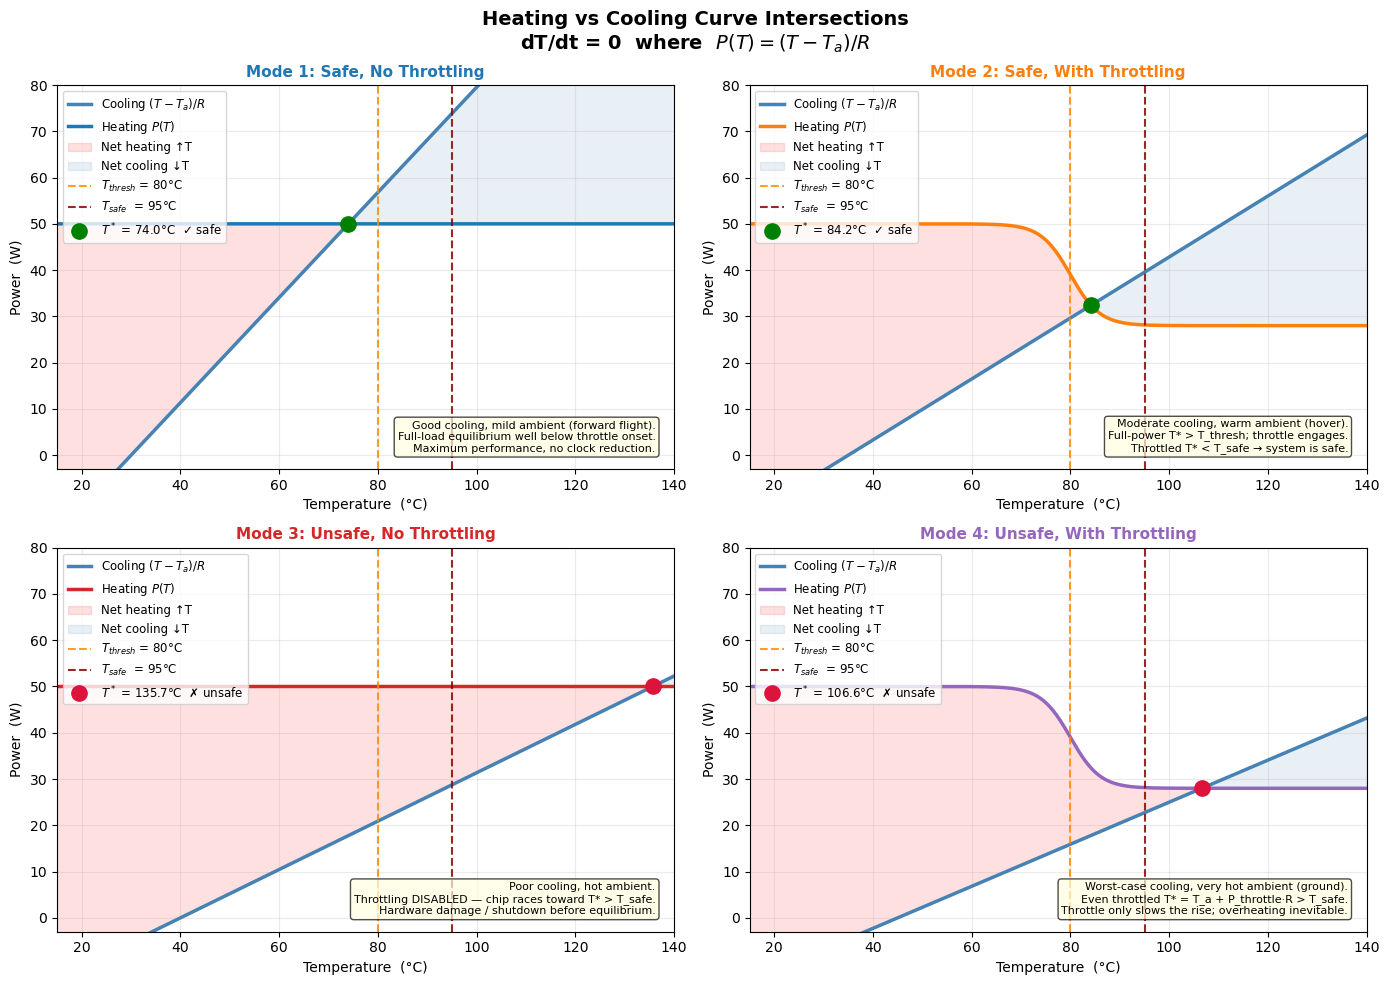

In [10]:
fig1, axes = plt.subplots(2, 2, figsize=(14, 10))
fig1.suptitle(
    "Heating vs Cooling Curve Intersections\n"
    r"dT/dt = 0  where  $P(T) = (T - T_a)/R$",
    fontsize=14, fontweight='bold'
)

T_plot = np.linspace(15, 140, 2000)

for ax, (mid, cfg) in zip(axes.flatten(), MODES.items()):
    R, T_a = cfg["R"], cfg["T_a"]

    cooling_W = (T_plot - T_a) / R
    heating_W = power_dissipated(T_plot, P_MAX, P_THROTTLE, T_THRESH, cfg["use_throttling"])

    ax.plot(T_plot, cooling_W, color="steelblue", lw=2.5, label=r"Cooling $(T-T_a)/R$")
    ax.plot(T_plot, heating_W, color=cfg["color"],  lw=2.5, label=r"Heating $P(T)$")

    # Shade net-heating (red) and net-cooling (blue) regions
    ax.fill_between(T_plot, heating_W, cooling_W,
                    where=(heating_W > cooling_W),
                    alpha=0.12, color="red",    label="Net heating ↑T")
    ax.fill_between(T_plot, heating_W, cooling_W,
                    where=(heating_W <= cooling_W),
                    alpha=0.12, color="steelblue", label="Net cooling ↓T")

    # Vertical threshold lines
    ax.axvline(T_THRESH, color="darkorange",  ls="--", lw=1.5, alpha=0.85,
               label=f"$T_{{thresh}}$ = {T_THRESH:.0f}°C")
    ax.axvline(T_SAFE,   color="darkred",     ls="--", lw=1.5, alpha=0.85,
               label=f"$T_{{safe}}$  = {T_SAFE:.0f}°C")

    # Mark equilibrium point T*
    T_star = sim[mid]["T_star"]
    if T_star is not None:
        y_star = (T_star - T_a) / R
        safe   = T_star < T_SAFE
        ax.plot(T_star, y_star, "o",
                color="green" if safe else "crimson",
                ms=11, zorder=6,
                label=f"$T^*$ = {T_star:.1f}°C  {'✓ safe' if safe else '✗ unsafe'}")

    ax.set_xlim(15, 140)
    ax.set_ylim(-3, 80)
    ax.set_xlabel("Temperature  (°C)", fontsize=10)
    ax.set_ylabel("Power  (W)", fontsize=10)
    ax.set_title(cfg["label"], fontsize=11, fontweight="bold", color=cfg["color"])
    ax.legend(fontsize=8.5, loc="upper left")
    ax.grid(True, alpha=0.25)

    ax.text(0.97, 0.04, cfg["description"],
            transform=ax.transAxes, fontsize=8, ha="right", va="bottom",
            bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.7))

plt.tight_layout()

### Time Evolution: Temperature and Power

Top panel: $T(t)$ for all four modes on one axis. The orange/red dashed lines mark the operational limits.

Key observations:
- All curves start at $T_a$ and heat at a rate set by $\tau = RC$.
- Modes 1 and 3 are monotone (power is constant); different only in whether they breach $T_\text{safe}$.
- Mode 2 shows a "knee" near $T_\text{thresh}$ where heating slows as the throttle fires, eventually flattening out below $T_\text{safe}$.
- Mode 4 also shows a knee but continues climbing past $T_\text{safe}$; throttling buys time but cannot hold the line.

Bottom panel: $P(t)$ — shows when/whether the throttle fires. Throttled modes (2 and 4) have power that ramps down as $T$ rises through $T_\text{thresh}$.

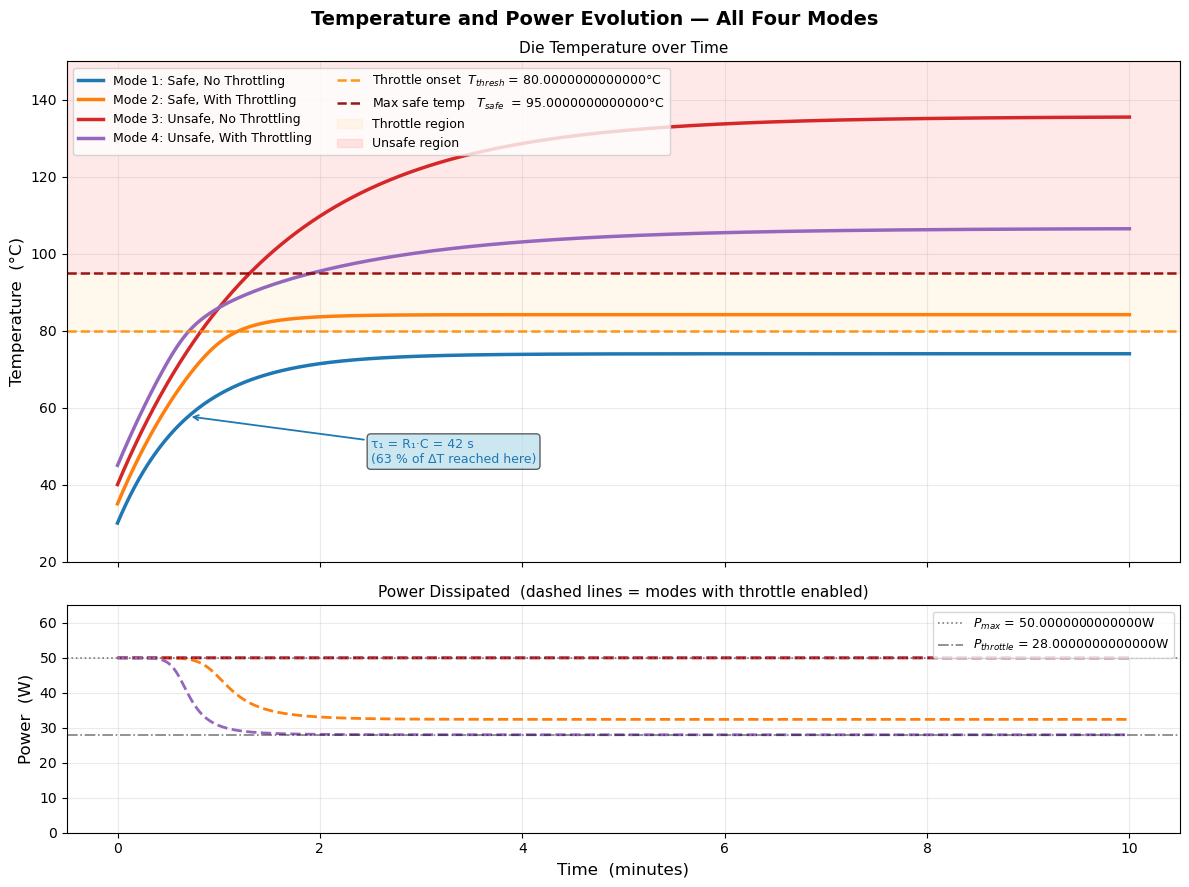

In [11]:
fig2, (ax_T, ax_P) = plt.subplots(
    2, 1, figsize=(12, 9), sharex=True,
    gridspec_kw={"height_ratios": [2.2, 1]}
)
fig2.suptitle("Temperature and Power Evolution — All Four Modes", fontsize=14, fontweight="bold")

for mid, cfg in MODES.items():
    r = sim[mid]
    t_min = r["t"] / 60.0
    ax_T.plot(t_min, r["T"], color=cfg["color"], lw=2.5, label=cfg["label"])
    ax_P.plot(t_min, r["P"], color=cfg["color"], lw=2.0, ls="--")

# Limit lines
ax_T.axhline(T_THRESH, color="darkorange", ls="--", lw=1.8, alpha=0.9,
             label=f"Throttle onset  $T_{{thresh}}$ = {T_THRESH}°C")
ax_T.axhline(T_SAFE,   color="darkred",    ls="--", lw=1.8, alpha=0.9,
             label=f"Max safe temp   $T_{{safe}}$  = {T_SAFE}°C")

# Shaded danger zones
ax_T.axhspan(T_THRESH, T_SAFE, color="orange", alpha=0.07, label="Throttle region")
ax_T.axhspan(T_SAFE,   150,    color="red",    alpha=0.09, label="Unsafe region")

# Annotate time-constant intuition on Mode 1 (clean, no throttle)
R1 = MODES[1]["R"]
tau1 = R1 * C
delta1 = P_MAX * R1                           # total ΔT = P·R
T63 = MODES[1]["T_a"] + 0.63 * delta1        # 63 % of ΔT = 1 time constant
ax_T.annotate(
    f"τ₁ = R₁·C = {tau1:.0f} s\n(63 % of ΔT reached here)",
    xy=(tau1 / 60, T63),
    xytext=(tau1 / 60 + 1.8, T63 - 12),
    arrowprops=dict(arrowstyle="->", color="tab:blue", lw=1.3),
    fontsize=9, color="tab:blue",
    bbox=dict(boxstyle="round", facecolor="lightblue", alpha=0.6),
)

ax_T.set_ylabel("Temperature  (°C)", fontsize=12)
ax_T.set_ylim(20, 150)
ax_T.legend(fontsize=9, loc="upper left", ncol=2)
ax_T.grid(True, alpha=0.25)
ax_T.set_title("Die Temperature over Time", fontsize=11)

ax_P.axhline(P_MAX,      color="black", ls=":",  lw=1.2, alpha=0.5,
             label=f"$P_{{max}}$ = {P_MAX}W")
ax_P.axhline(P_THROTTLE, color="black", ls="-.", lw=1.2, alpha=0.5,
             label=f"$P_{{throttle}}$ = {P_THROTTLE}W")
ax_P.set_ylabel("Power  (W)", fontsize=12)
ax_P.set_xlabel("Time  (minutes)", fontsize=12)
ax_P.set_ylim(0, 65)
ax_P.legend(fontsize=9, loc="upper right")
ax_P.grid(True, alpha=0.25)
ax_P.set_title("Power Dissipated  (dashed lines = modes with throttle enabled)", fontsize=11)

plt.tight_layout()

### Airflow Sensitivty Map

Left: $R(v)$ curve showing how cooling improves with airspeed. The four mode operating points are overlaid. Notice that even a few m/s of prop-wash dramatically lowers $R$.

Right: Throttled steady-state temperature $T^*(v)$ for several ambient temps. Any curve that rises above $T_\text{safe}$ at low $v$ is a Mode-4 scenario. This plot directly answers: "what is the minimum safe airspeed for a given ambient temperature?"

Practical use: overlay the $T^*$ contour map with your flight envelope (hover vs cruise vs idle-on-ground) to identify thermal risk windows.

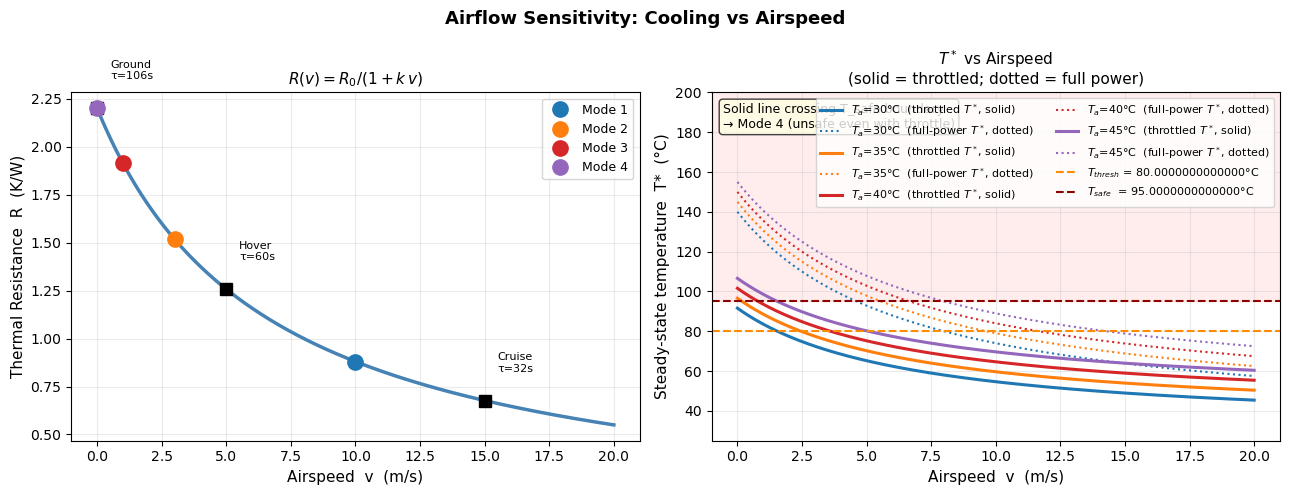

In [12]:
fig3, (ax_R, ax_Tss) = plt.subplots(1, 2, figsize=(13, 5))
fig3.suptitle("Airflow Sensitivity: Cooling vs Airspeed", fontsize=13, fontweight="bold")

v_arr   = np.linspace(0, 20, 800)
R_arr   = thermal_resistance(v_arr)
tau_arr = R_arr * C

ax_R.plot(v_arr, R_arr, color="steelblue", lw=2.5)
ax_R.set_xlabel("Airspeed  v  (m/s)", fontsize=11)
ax_R.set_ylabel("Thermal Resistance  R  (K/W)", fontsize=11)
ax_R.set_title(r"$R(v) = R_0 / (1 + k\,v)$", fontsize=11)
ax_R.grid(True, alpha=0.25)

# Annotate time constants at a few representative speeds
for v_mark, label in [(0, "Ground"), (5, "Hover"), (15, "Cruise")]:
    R_m   = thermal_resistance(v_mark)
    tau_m = R_m * C
    ax_R.plot(v_mark, R_m, "s", color="black", ms=8, zorder=5)
    ax_R.annotate(f"{label}\nτ={tau_m:.0f}s",
                  xy=(v_mark, R_m), xytext=(v_mark + 0.5, R_m + 0.15),
                  fontsize=8, color="black")

for mid, cfg in MODES.items():
    ax_R.plot(cfg["v_airspeed"], cfg["R"], "o", color=cfg["color"], ms=11,
              label=f"Mode {mid}", zorder=6)
ax_R.legend(fontsize=9)

# Right plot: T_ss_throttle(v) for different ambient temperatures
T_a_sweep  = [30, 35, 40, 45]
color_sweep = ["tab:blue", "tab:orange", "tab:red", "tab:purple"]

for T_a_val, col in zip(T_a_sweep, color_sweep):
    Tss_throt = T_a_val + P_THROTTLE * R_arr
    Tss_full  = T_a_val + P_MAX      * R_arr
    ax_Tss.plot(v_arr, Tss_throt, color=col, lw=2.2,
                label=f"$T_a$={T_a_val}°C  (throttled $T^*$, solid)")
    ax_Tss.plot(v_arr, Tss_full,  color=col, lw=1.5, ls=":",
                label=f"$T_a$={T_a_val}°C  (full-power $T^*$, dotted)")

ax_Tss.axhline(T_THRESH, color="darkorange", ls="--", lw=1.5,
               label=f"$T_{{thresh}}$ = {T_THRESH}°C")
ax_Tss.axhline(T_SAFE,   color="darkred",    ls="--", lw=1.5,
               label=f"$T_{{safe}}$  = {T_SAFE}°C")
ax_Tss.axhspan(T_SAFE, 200, color="red", alpha=0.07)

ax_Tss.set_ylim(25, 200)
ax_Tss.set_xlabel("Airspeed  v  (m/s)", fontsize=11)
ax_Tss.set_ylabel("Steady-state temperature  T*  (°C)", fontsize=11)
ax_Tss.set_title("$T^*$ vs Airspeed\n(solid = throttled; dotted = full power)", fontsize=11)
ax_Tss.legend(fontsize=8, loc="upper right", ncol=2)
ax_Tss.grid(True, alpha=0.25)

ax_Tss.text(
    0.02, 0.97,
    "Solid line crossing T_safe boundary\n→ Mode 4 (unsafe even with throttle)",
    transform=ax_Tss.transAxes, ha="left", va="top", fontsize=9,
    bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.75)
)

plt.tight_layout()

### Phase Portrait

The phase portrait distills the entire dynamics into a single curve.

How to read it:
- Where $dT/dt > 0$  (curve above zero):  temperature is RISING
- Where $dT/dt < 0$  (curve below zero):  temperature is FALLING
- Where $dT/dt = 0$  (curve crosses zero): $T^*$ = steady state

Stability of a crossing:
- If the curve crosses zero from above (positive → negative), it is a STABLE fixed point — any perturbation is damped back.
- If it crosses from below, it is unstable (not present here for normal $R$).

With throttling (Modes 2 and 4), the power sigmoid creates a notch in the $dT/dt$ curve near $T_\text{thresh}$, pulling $T^*$ downward relative to the no-throttle case. In Mode 2 the notch is deep enough to push $T^*$ below $T_\text{safe}$. In Mode 4 the notch is present but $T^*$ remains above $T_\text{safe}$.

Without throttling (Modes 1 and 3), the $dT/dt$ curve is a clean straight line (constant $P$, cooling proportional to $T$).  It crosses zero at $T^* = T_a + P_\text{max}R$.

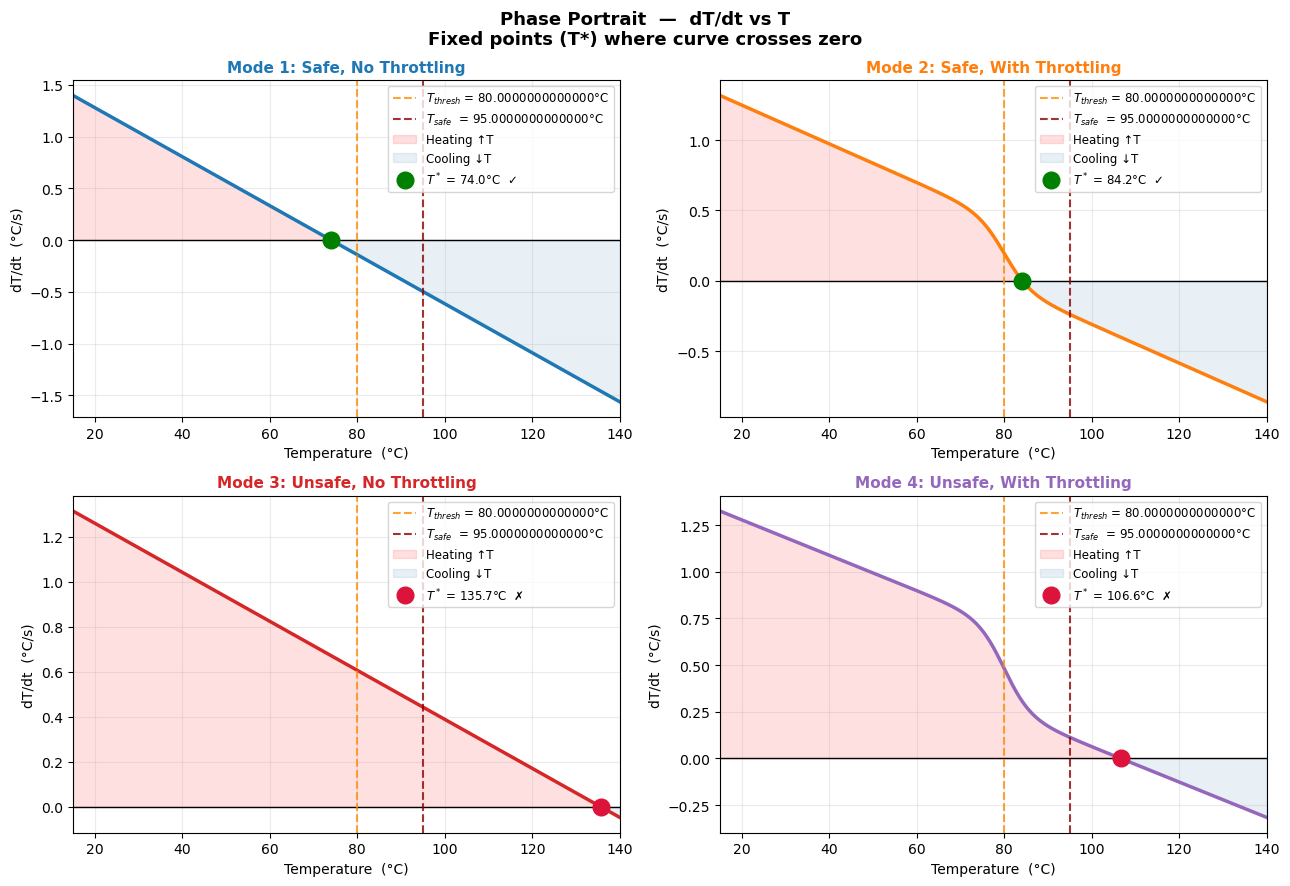

In [13]:
fig4, axes4 = plt.subplots(2, 2, figsize=(13, 9))
fig4.suptitle(
    "Phase Portrait  —  dT/dt vs T\n"
    "Fixed points (T*) where curve crosses zero",
    fontsize=13, fontweight="bold"
)

T_pp = np.linspace(15, 140, 2000)

for ax, (mid, cfg) in zip(axes4.flatten(), MODES.items()):
    R, T_a = cfg["R"], cfg["T_a"]
    P_curve    = power_dissipated(T_pp, P_MAX, P_THROTTLE, T_THRESH, cfg["use_throttling"])
    dT_curve   = (P_curve - (T_pp - T_a) / R) / C

    ax.plot(T_pp, dT_curve, color=cfg["color"], lw=2.5)
    ax.axhline(0, color="black", lw=1.0)
    ax.axvline(T_THRESH, color="darkorange", ls="--", lw=1.5, alpha=0.8,
               label=f"$T_{{thresh}}$ = {T_THRESH}°C")
    ax.axvline(T_SAFE,   color="darkred",    ls="--", lw=1.5, alpha=0.8,
               label=f"$T_{{safe}}$  = {T_SAFE}°C")

    ax.fill_between(T_pp, dT_curve, 0,
                    where=(dT_curve > 0), alpha=0.12, color="red",
                    label="Heating ↑T")
    ax.fill_between(T_pp, dT_curve, 0,
                    where=(dT_curve < 0), alpha=0.12, color="steelblue",
                    label="Cooling ↓T")

    T_star = sim[mid]["T_star"]
    if T_star is not None:
        safe = T_star < T_SAFE
        ax.plot(T_star, 0, "o",
                color="green" if safe else "crimson",
                ms=12, zorder=6,
                label=f"$T^*$ = {T_star:.1f}°C  {'✓' if safe else '✗'}")

    ax.set_xlim(15, 140)
    ax.set_xlabel("Temperature  (°C)", fontsize=10)
    ax.set_ylabel("dT/dt  (°C/s)", fontsize=10)
    ax.set_title(cfg["label"], fontsize=11, fontweight="bold", color=cfg["color"])
    ax.legend(fontsize=8.5, loc="upper right")
    ax.grid(True, alpha=0.25)

plt.tight_layout()